# DARTS Multi-Fidelity NAS — Time Series Example

End-to-end pipeline:
1. Generate a synthetic multi-component time series
2. Build windowed `DataLoader`s (train / val / test)
3. Initialise `DARTSTrainer`
4. Run `multi_fidelity_search`
5. Inspect the discovered architecture and final model metrics

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from foreblocks.darts import DARTSTrainer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1  Synthetic time series

We build a 3-channel signal that combines:
- a long trend
- two sinusoidal seasonalities (periods 12 and 5)
- a short-memory autoregressive component
- low-amplitude Gaussian noise

This gives the NAS enough structure to exploit without making the task trivial.

Series shape: (1500, 2)  (should be (1500, 2))


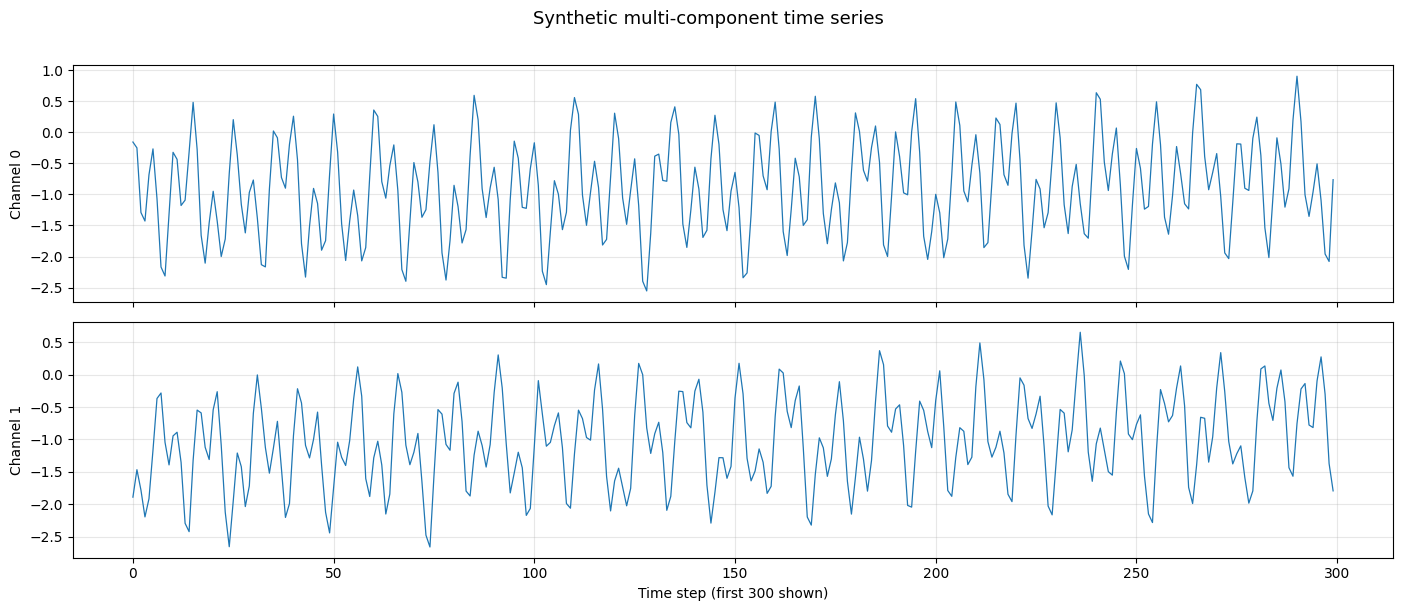

In [2]:
N = 1500          # total time steps
N_CHANNELS = 2    # multivariate channels
SEQ_LEN = 20      # look-back window fed to the model
HORIZON = 5      # forecast horizon

def make_ts(n: int, n_channels: int, seed: int = 0) -> np.ndarray:
    """Return (n, n_channels) float32 array."""
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=np.float64)

    channels = []
    angular_freqs = [2 * np.pi / 12, 2 * np.pi / 5, 2 * np.pi / 25]
    for ch in range(n_channels):
        # trend
        trend = 0.002 * t + rng.uniform(-0.5, 0.5)
        # seasonality blend
        a1, a2, a3 = rng.uniform(0.6, 1.2, 3)
        seasonal = (
            a1 * np.sin(angular_freqs[0] * t + rng.uniform(0, 2 * np.pi))
            + a2 * np.cos(angular_freqs[1] * t + rng.uniform(0, 2 * np.pi))
            + 0.3 * a3 * np.sin(angular_freqs[2] * t + rng.uniform(0, 2 * np.pi))
        )
        # short AR(1)
        ar = np.zeros(n)
        phi = rng.uniform(0.55, 0.75)
        for i in range(1, n):
            ar[i] = phi * ar[i - 1] + rng.normal(0, 0.25)
        channels.append(trend + seasonal + 0.4 * ar + rng.normal(0, 0.08, n))

    data = np.stack(channels, axis=1).astype(np.float32)
    # StandardScaler per channel
    data = (data - data.mean(0, keepdims=True)) / (data.std(0, keepdims=True) + 1e-8)
    return data


data = make_ts(N, N_CHANNELS, seed=SEED)
print(f'Series shape: {data.shape}  (should be ({N}, {N_CHANNELS}))')

fig, axes = plt.subplots(N_CHANNELS, 1, figsize=(14, 3 * N_CHANNELS), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(data[:300, ch], lw=0.9)
    ax.set_ylabel(f'Channel {ch}')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time step (first 300 shown)')
fig.suptitle('Synthetic multi-component time series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2  Windowed DataLoaders

In [ ]:
def make_windows(
    data: np.ndarray,
    seq_len: int,
    horizon: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Sliding-window X/Y pairs.

    X: (n_windows, seq_len, n_channels)
    Y: (n_windows, horizon, n_channels)   — multi-step forecast
    """
    xs, ys = [], []
    end = len(data) - horizon
    for i in range(seq_len, end + 1):
        xs.append(data[i - seq_len : i])
        ys.append(data[i : i + horizon])
    X = torch.tensor(np.stack(xs), dtype=torch.float32)
    Y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return X, Y


X, Y = make_windows(data, SEQ_LEN, HORIZON)
print(f'Windows — X: {X.shape}   Y: {Y.shape}')

n = len(X)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

X_tr, Y_tr = X[:n_train],          Y[:n_train]
X_va, Y_va = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_te, Y_te = X[n_train+n_val:],    Y[n_train+n_val:]

print(f'Train: {n_train}  Val: {n_val}  Test: {n_test}')

# DARTSTrainer expects (x, y) batches where y has shape (B, horizon, C)
# Keeping (B, H, C) here; the Huber loss averages over all elements.
BATCH = 32
_pin = (DEVICE == "cuda")   # pinned memory enables async CPU→GPU DMA transfers

train_loader = DataLoader(TensorDataset(X_tr, Y_tr), batch_size=BATCH, shuffle=True,  drop_last=True,  pin_memory=_pin)
val_loader   = DataLoader(TensorDataset(X_va, Y_va), batch_size=BATCH, shuffle=False, drop_last=False, pin_memory=_pin)
test_loader  = DataLoader(TensorDataset(X_te, Y_te), batch_size=BATCH, shuffle=False, drop_last=False, pin_memory=_pin)

print(f'Batches per epoch — train: {len(train_loader)}  val: {len(val_loader)}')


Windows — X: torch.Size([1476, 20, 2])   Y: torch.Size([1476, 5, 2])
Train: 1033  Val: 221  Test: 222
Batches per epoch — train: 32  val: 7


## 3  DARTSTrainer setup

We use a compact operation set that covers most interesting inductive biases:

| Op | Inductive bias |
|---|---|
| Identity | skip / residual |
| ResidualMLP | pointwise mixing |
| TimeConv | local temporal patterns |
| TCN | multi-scale dilated convolutions |
| Fourier | global frequency features |
| GRN | gating with context |

> **Mamba note**: `MambaOp` is intentionally excluded from the input/backbone
> cell operations — its causal, autoregressive inductive bias belongs in the
> decoder, not in the shared feature-extraction backbone.  You can still add it
> to the `DARTSTrainer(all_ops=...)` list if you want to experiment.

### Architecture topology (`arch_mode`)

Each candidate model can be built with one of three topologies, which DARTS
now searches over jointly with operation selection:

| `arch_mode` | Description |
|---|---|
| `encoder_decoder` | Full seq2seq: `MixedEncoder` → autoregressive `MixedDecoder` loop |
| `encoder_only` | Non-autoregressive: `MixedEncoder` → mean-pool → linear forecast head |
| `decoder_only` | Causal backbone: DARTS cells → last-token → linear forecast head |

The `arch_modes` list passed to `DARTSTrainer` controls which topologies are
included in the random candidate pool during multi-fidelity search.  Pass a
single-element list to fix the topology and search only over operations/dims.


In [4]:
OPS = [
    'Identity',
    'ResidualMLP',
    'TimeConv',
    'TCN',
    'Fourier',
    'GRN',
]

trainer = DARTSTrainer(
    input_dim=N_CHANNELS,
    hidden_dims=[32, 64],     # smaller dims for a quick demo
    forecast_horizon=HORIZON,
    seq_length=SEQ_LEN,
    device=DEVICE,
    all_ops=OPS,
    # Search over all three topologies simultaneously.
    # Fix to a single entry to restrict the search, e.g.:
    #   arch_modes=['encoder_only']
    #   arch_modes=['decoder_only']
    arch_modes=['encoder_decoder', 'encoder_only', 'decoder_only'],
)


DARTSTrainer initialised on cuda
  input_dim=2  forecast_horizon=5
  operations available: 6
  arch_modes: ['encoder_decoder', 'encoder_only', 'decoder_only']


In [5]:
import torch
from foreblocks.darts.architecture.core_blocks import TimeSeriesDARTS

_seq_len, _horizon, _channels = SEQ_LEN, HORIZON, N_CHANNELS
_x = torch.randn(4, _seq_len, _channels)

# --- quick sanity-check: all three topologies forward-pass cleanly ---
for mode in ('encoder_decoder', 'encoder_only', 'decoder_only'):
    m = TimeSeriesDARTS(
        input_dim=_channels,
        hidden_dim=32,
        latent_dim=32,
        forecast_horizon=_horizon,
        seq_length=_seq_len,
        selected_ops=['Identity', 'TimeConv', 'Fourier'],
        arch_mode=mode,
    )
    m.eval()
    with torch.no_grad():
        y = m(_x)
    print(f"arch_mode={mode!r:20s}  output shape: {tuple(y.shape)}")


arch_mode='encoder_decoder'     output shape: (4, 5, 2)
arch_mode='encoder_only'        output shape: (4, 5, 2)
arch_mode='decoder_only'        output shape: (4, 5, 2)


## 4  Multi-fidelity search

The pipeline runs 5 phases automatically:

1. **Phase 1** — rapid zero-cost scoring of `num_candidates` random architectures
2. **Phase 2** — select `top_k` by aggregate zero-cost score
3. **Phase 3** — short bilevel DARTS training (`search_epochs`) for each top-k model
4. **Phase 4** — pick the best by validation loss, derive the discrete architecture
5. **Phase 5** — full final training (`final_epochs`) from (optionally re-initialised) weights

Adjust `num_candidates`, `search_epochs`, and `final_epochs` to taste — the values below are intentionally small for a fast demo run.

In [6]:
results = trainer.multi_fidelity_search(
    train_loader,
    val_loader,
    test_loader,
    num_candidates=8,              # random architectures to zero-cost score
    top_k=3,                       # advance to short DARTS training
    search_epochs=15,              # bilevel DARTS epochs per top-k candidate
    final_epochs=40,               # full final training epochs
    max_samples=16,                # zero-cost evaluation sample budget
    max_workers=1,                 # sequential (set higher for parallel)
    retrain_final_from_scratch=True,
    discrete_arch_threshold=0.25,
    # AMP halves memory and speeds up ~1.5–2x on CUDA; no-op on CPU
    use_amp=(DEVICE == "cuda"),
)

Evaluating candidate 0 with config: ['Identity', 'Fourier'], hidden_dim=64, num_cells=1, num_nodes=3, arch_mode=encoder_only
   Metrics: {'metrics': {'params': 418604.0, 'conditioning': 3.0746599393911596, 'naswot': 68.61569351885434, 'activation_diversity': 0.0, 'flops': 8355840.0, 'grasp': -702.1182643053141, 'fisher': 5.129295548452579, 'snip': 0.24150054607391147, 'sensitivity': 0.00967931654304266, 'jacobian': -4.050798173848518, 'synflow': 0.005280205662557046}, 'success_rates': {'params': True, 'conditioning': True, 'naswot': True, 'activation_diversity': True, 'flops': True, 'grasp': True, 'fisher': True, 'snip': True, 'sensitivity': True, 'jacobian': True, 'synflow': True}, 'error_messages': {}, 'aggregate_score': -1.316434074394751, 'config': Config(max_samples=16, max_outputs=10, eps=1e-08, timeout=30.0, enable_mixed_precision=False, jacobian_probes=1, snip_at_init=True, snip_mode='current', heavy_metrics_batches=1, gradient_max_samples=2, fisher_per_sample=False, conditioni

DARTS:  33%|███▎      | 5/15 [00:05<00:09,  1.04epoch/s, train=0.0577, val=0.0571, best=0.0571, patience=0/15]

  [Arch Grad] enc=1.200970e-04, dec=1.724140e-04, cos=-0.4442, shared=False
   [Arch Update] norm: top=1, choice=instance_norm, weight=0.3340, dL1=0.000000
   [Arch Update] forecast_encoder: top=2, choice=transformer, weight=0.3366, dL1=0.000000
   [Arch Update] forecast_decoder: top=0, choice=lstm, weight=0.3375, dL1=0.000000
   [Arch Update] attention_bridge: top=2, choice=choice_2, weight=0.3400, dL1=0.000000
   [Edge Update] mean_top=0.5185, mean_dL1=0.000000, samples=[cell_0_edge_0:ResidualMLP@0.545, cell_0_edge_1:Identity@0.501]


DARTS:  60%|██████    | 9/15 [00:08<00:05,  1.05epoch/s, train=0.0685, val=0.0917, best=0.0571, patience=4/15]

  [Arch Grad] enc=2.018445e-04, dec=3.018788e-04, cos=-0.4082, shared=False
  [Arch Grad] enc=2.874823e-04, dec=3.416478e-04, cos=-0.3941, shared=False
   [Arch Update] norm: top=0, choice=revin, weight=0.3345, dL1=0.005014
   [Arch Update] forecast_encoder: top=2, choice=transformer, weight=0.3395, dL1=0.005757
   [Arch Update] forecast_decoder: top=0, choice=lstm, weight=0.3403, dL1=0.005562
   [Arch Update] attention_bridge: top=2, choice=choice_2, weight=0.3413, dL1=0.005464
   [Edge Update] mean_top=0.5361, mean_dL1=0.109135, samples=[cell_0_edge_0:Identity@0.544, cell_0_edge_1:ResidualMLP@0.551]
   [Edge Sharpen] weight=0.0087, entropy=0.4904


...

Final Training: 100%|██████████| 40/40 [00:17<00:00,  2.31epoch/s, train=0.0107, val=0.0126, best_val=0.0126, patience=0/20, swa=ok]



Finalizing SWA model...


SWA val loss: 0.017290 vs best: 0.012574
Keeping original best model.

Evaluating on test set...


Test Evaluation: 100%|██████████| 7/7 [00:00<00:00, 66.72batch/s, test_loss=0.0095]


Training curve saved to final_model_training.pdf


## 5  Inspect results

In [7]:
best = results['best_candidate']
final = results['final_results']

print('=== Best candidate ===')
print(f"  Zero-cost score : {best['candidate']['score']:.4f}")
print(f"  Selected ops    : {best['candidate'].get('selected_ops', 'N/A')}")
print(f"  Hidden dim      : {best['candidate'].get('hidden_dim')}")
print(f"  Val loss (derived): {best['val_loss']:.6f}")

print('\n=== Final model ===')
# print(f"  Best val loss   : {final['best_val_loss']:.6f}")
fm = final.get('final_metrics', {})
for k, v in fm.items():
    print(f"  {k:20s}: {v:.6f}")

=== Best candidate ===
  Zero-cost score : 4.4393
  Selected ops    : ['Identity', 'ResidualMLP']
  Hidden dim      : 32
  Val loss (derived): 0.057153

=== Final model ===
  mse                 : 0.039718
  rmse                : 0.199294
  mae                 : 0.158118
  mape                : 64.367581
  r2_score            : 0.924862


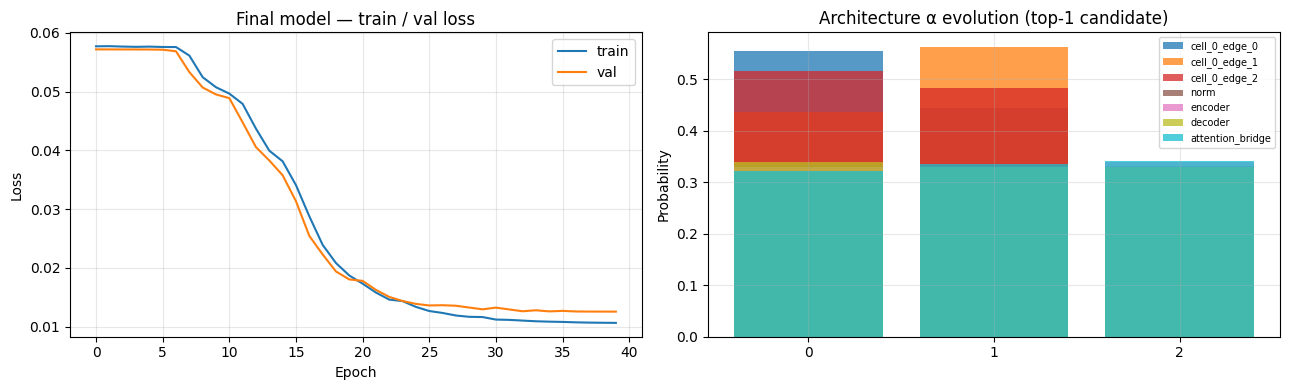

In [8]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].set_title('Final model — train / val loss')
axes[0].plot(final['train_losses'], label='train')
axes[0].plot(final['val_losses'],   label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# α evolution for the best search candidate (phase-3 results)
alpha_values = results['trained_candidates'][0]['search_results']['alpha_values']
if alpha_values:
    axes[1].set_title('Architecture α evolution (top-1 candidate)')
    snap = alpha_values[-1]  # last snapshot
    names  = [s[0] for s in snap]
    probs  = [s[1] for s in snap]
    n_alphas = len(names)
    cmap = plt.cm.get_cmap('tab10', n_alphas)
    for i, (nm, pr) in enumerate(zip(names, probs)):
        axes[1].bar(range(len(pr)), pr, label=nm, alpha=0.75, color=cmap(i))
    axes[1].set_xticks(range(max(len(p) for p in probs)))
    axes[1].set_ylabel('Probability')
    axes[1].legend(fontsize=7, loc='upper right')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No α snapshots recorded', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 6  Qualitative forecast check

Roll the final model over the test set and plot predicted vs actual for one channel.

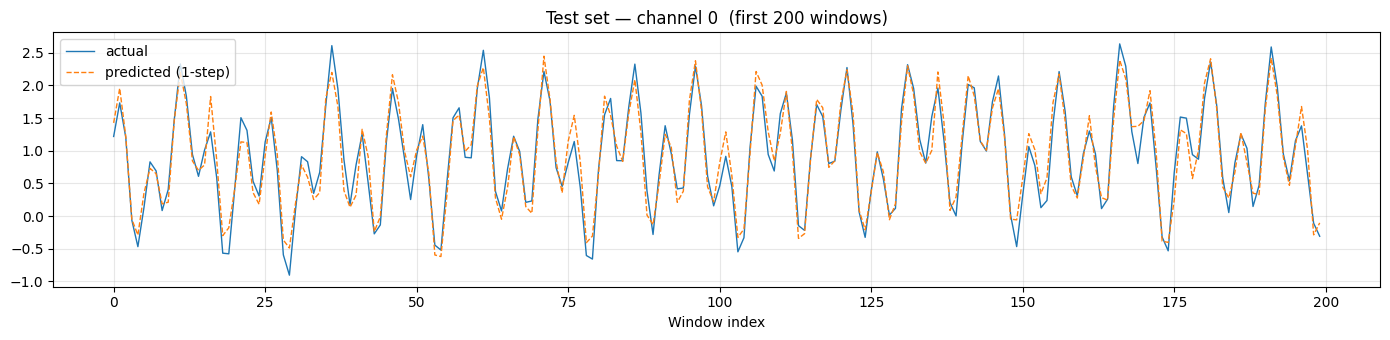

Test MSE (1-step, ch. 0): 0.04065   MAE: 0.16343


In [9]:
final_model = results['final_model']
final_model.eval()

preds_list, actuals_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = final_model(xb).cpu().numpy()  # (B, H, C) or (B, H*C)
        preds_list.append(out)
        actuals_list.append(yb.numpy())

preds   = np.concatenate(preds_list,   axis=0)  # (N_test, ...)
actuals = np.concatenate(actuals_list, axis=0)

# Reshape if model returns flat output
if preds.ndim == 2 and preds.shape[1] == HORIZON * N_CHANNELS:
    preds   = preds.reshape(-1, HORIZON, N_CHANNELS)
    actuals = actuals.reshape(-1, HORIZON, N_CHANNELS)

# Plot the 1-step-ahead prediction for channel 0
CH = 0
pred_1step   = preds[:, 0, CH]
actual_1step = actuals[:, 0, CH]

T_show = min(200, len(pred_1step))
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(actual_1step[:T_show], lw=1.0, label='actual')
ax.plot(pred_1step[:T_show],   lw=1.0, linestyle='--', label='predicted (1-step)')
ax.set_title(f'Test set — channel {CH}  (first {T_show} windows)')
ax.set_xlabel('Window index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mse  = float(np.mean((pred_1step - actual_1step) ** 2))
mae  = float(np.mean(np.abs(pred_1step - actual_1step)))
print(f'Test MSE (1-step, ch. {CH}): {mse:.5f}   MAE: {mae:.5f}')

## 7  Discrete architecture summary

In [10]:
if hasattr(final_model, 'derive_discrete_architecture'):
    discrete = final_model.derive_discrete_architecture(threshold=0.25)
    print('Discrete architecture:')
    for k, v in discrete.items():
        print(f'  {k}: {v}')
else:
    # Fall back to alpha inspection via trainer's AlphaTracker
    print('Alpha probabilities at convergence:')
    final_model.eval()
    with torch.no_grad():
        for name, probs in trainer.alpha_tracker.extract_alpha_values(final_model):
            top_idx = int(np.argmax(probs))
            print(f'  {name}: top_idx={top_idx}  probs={np.round(probs, 3)}')

Discrete architecture:
  norm: {'type': 'revin', 'weight': 1.0, 'passed_threshold': True}
  encoder: {'type': 'op_0', 'weight': 1.0, 'passed_threshold': True}
  decoder: {'type': 'op_0', 'weight': 1.0, 'passed_threshold': True}


In [11]:
# Timing summary across phases
stats = results.get('stats', {})
phase_summary = stats.get('phase_summary', {})
if phase_summary:
    print('Wall-clock time per phase:')
    total = 0.0
    for ph, info in phase_summary.items():
        t = info.get('wall_time_sec', 0.0)
        total += t if ph != 'total' else 0.0
        print(f'  {ph:10s}: {t:.2f}s')
    print(f'  {"TOTAL":10s}: {total:.2f}s')
else:
    import time as _time
    print('(stats not collected; pass collect_stats=True to capture timing)')

(stats not collected; pass collect_stats=True to capture timing)
